In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/home/filip/Git_Code/')
sys.path.append('/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/')

from demler_tools.file_manager import path_management, io
from demler_tools.file_manager import file_management_local_backend

import data_analysis as da
from glob import glob                                                                             
import os 

In [2]:
# Initialize demler_tools path management
path_management.initialize(project_name='psBQP-keldysh')

Successfully initialized path management with following parameters:
     username:                fmarijanovic
     project name:            psBQP-keldysh
     controlling machine:     laptop
     library version:         v2.3.0-beta-17-g6b0081d
     auto SSH transfer:       True
     default save location:   /home/filip/Documents/Research/data_files/
     LTS mount point:         /home/filip
     email domain:            phys.ethz.ch
     cluster OS:              Ubuntu
     cluster partition:       work
     SSH host file:           /home/filip/.ssh/known_hosts
     SSH key file:            /home/filip/.ssh/id_ed25519_euler
     default modules:         {'CentOS': 'gcc/8.2.0 python/3.11.2', 'Ubuntu': 'stack/2024-06 python/3.11.6'}


In [3]:
crt_controlling_machine = 'laptop'

file_management_local_backend.simple_result_scan(_scan_path = path_management.default_simulation_data_path(running_machine = crt_controlling_machine), display_full_parameters = True)

Directory 1782196485 is missing common arguments file! Please construct it.
Directory 1782196485:

      Human-readable file created at Tue Jun 23 08:34:45 2026, using demler_tools v2.3.0-beta-17-g6b0081d
      Path convention: v3
      Created by user: fmarijanovic
      Project name: psBQP-keldysh
      
      Calculation type: Undriven Thermal equilibrium
      Number of jobs to run: 12
      
      Task summary: Equilibrium generation -- lower damping
      
      Current folder state: completed
      
      Calculation log:
      [Tue Jun 23 08:38:54 2026] Updated directory state to the following: submitted
      [Tue Jun 23 08:38:54 2026] Submitted folder job to cluster with controller cluster_files/cluster_control_0_main.sh and under ID: 4340923
      [Tue Jun 23 08:38:55 2026] Submitted automatic postprocess job to cluster with controller cluster_files/cluster_control_0_post.sh and under ID: 4340924
      [Tue Jun 23 11:47:22 2026] Recovered slurm metadata for job ID: 4340923
 

['1781865131',
 '1781865083',
 '1781864899',
 '1781864886',
 '1781864880',
 '1781864871',
 '1781818360',
 '1781818348',
 '1781818338',
 '1781818237',
 '1781818157',
 '1781711040',
 '1781709737',
 '1781705963',
 '1781704291',
 '1781703060',
 '1781703037',
 '1781702934',
 '1781702763']

In [4]:
import pickle

def load_gap_vs_temperature(filename=None, directory='equilibrium_results'):
    """
    Load gap vs temperature data from text file.

    If filename is None, loads the most recent gap_vs_T file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_vs_T_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_vs_T files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    T = data[:, 0]           # Temperature
    Re_gap = data[:, 1]      # Re(Gap)
    Im_gap = data[:, 2]      # Im(Gap)
    abs_gap = data[:, 3]     # |Gap|
    error = data[:, 4]       # Error

    # Reconstruct complex gap
    gap = Re_gap + 1j * Im_gap

    return {
        'temperature': T,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'error': error
    }

  # ============================================================================
  # Load Gap & Current vs Vector Potential Data
  # ============================================================================

def load_gap_current_vs_A(filename=None, directory='equilibrium_results'):
    """
    Load gap and current vs vector potential data from text file.

    If filename is None, loads the most recent gap_current_vs_A file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_current_vs_A_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_current_vs_A files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    A = data[:, 0]              # Vector potential
    Re_gap = data[:, 1]         # Re(Gap)
    Im_gap = data[:, 2]         # Im(Gap)
    abs_gap = data[:, 3]        # |Gap|
    Re_current = data[:, 4]     # Re(Current)
    Im_current = data[:, 5]     # Im(Current)
    abs_current = data[:, 6]    # |Current|
    error = data[:, 7]          # Gap error

    # Reconstruct complex values
    gap = Re_gap + 1j * Im_gap
    current = Re_current + 1j * Im_current

    return {
        'vector_potential': A,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'current': current,
        'current_real': Re_current,
        'current_imag': Im_current,
        'current_magnitude': abs_current,
        'error': error
    }

def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

temp_data = load_gap_vs_temperature('./equilibrium_results/gap_vs_T_sweep_20260610_110914.txt')
A_data = load_gap_current_vs_A('./equilibrium_results/gap_current_vs_A_sweep_20260610_112441.txt')
# ============================================================================
# Quick Access to Data
# ============================================================================

# Temperature sweep
eq_T = temp_data['temperature']
eq_gap_T = temp_data['gap']
eq_gap_mag_T = temp_data['gap_magnitude']

# Vector potential sweep
eq_A = A_data['vector_potential']
eq_gap_A = A_data['gap']
eq_current_A = A_data['current']
eq_gap_mag_A = A_data['gap_magnitude']
eq_current_mag_A = A_data['current_magnitude']

full_file = load_file('equilibrium_comparison_trash.dat')
print(full_file.keys())

eq_T_trash = full_file['temp_list']
eq_gap_T_trash = full_file['t_scan_gaps']
eq_gap_mag_T_trash = full_file['t_scan_gaps']

# Vector potential sweep
eq_A_trash = full_file['q_scan_Qs']
eq_gap_A_trash = full_file['q_scan_gaps'][0,:]
eq_current_A_trash = full_file['q_scan_currents'][0,:]
eq_gap_mag_A_trash = full_file['q_scan_gaps'][0,:]
eq_current_mag_A_trash = full_file['q_scan_currents'][0,:]


full_file = load_file('equilibrium_comparison.dat')
print(full_file.keys())

eq_T = full_file['temp_list']
eq_gap_T = full_file['t_scan_gaps']
eq_gap_mag_T = full_file['t_scan_gaps']

# Vector potential sweep
eq_A = full_file['q_scan_Qs']
eq_gap_A = full_file['q_scan_gaps'][0,:]
eq_current_A = full_file['q_scan_currents'][0,:]
eq_gap_mag_A = full_file['q_scan_gaps'][0,:]
eq_current_mag_A = full_file['q_scan_currents'][0,:]


print(eq_A.shape)
print(eq_gap_A.shape)
print(eq_current_A.shape)

Loading: ./equilibrium_results/gap_vs_T_sweep_20260610_110914.txt
Loading: ./equilibrium_results/gap_current_vs_A_sweep_20260610_112441.txt
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'temp_list', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'temp_list', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(30,)
(30,)
(30,)


In [12]:
#check_timestamp = '1780759388'  # Timestamp folder to analyze -- refernce one from equilibrium
check_timestamp = '1782196465' # 1780851032' #'1780846595'
check_job_index = 0            # Job index to analyze
print(f"Analyzing timestamp: {check_timestamp}, job index: {check_job_index}")

Analyzing timestamp: 1782196465, job index: 0


In [9]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

## 0. Getting parameters

In [11]:
parameters_ts = '1782196465'
da.print_all_parameters(parameters_ts)


SIMULATION PARAMETERS
Timestamp: 1782196465
Job Index: 0
  num_timesteps                  = 300

  ────────────────────────────────────────────────────────────
  ║ SYSTEM PARAMETERS
  ────────────────────────────────────────────────────────────
    critical_temperature           = 1
    temperature                    = 0.100000
    eta                            = 0.150000
  initial_state_timestamp        = None
  initial_state_index            = 0

  ────────────────────────────────────────────────────────────
  ║ GRID PARAMETERS
  ────────────────────────────────────────────────────────────
    time_sampling                  = 2001
    time_duration                  = 42.097342
    dt                             = 0.021049
  field_type                     = None
  track_every_n                  = None
  save_full_state                = True
  save_filename                  = /cluster/work/demler/project_active/fmarijanovic/savefiles/psBQP-keldysh/simulation_results/1782196465/result

# 1. Validation Checks

-1
1

NORMALIZATION CHECK - Maximum Error Indices

τ_0 component:
  g^R normalization: max_error = 2.7316e-07 at index 1699
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 1.3449e-01 at index 1999
  g^K normalization: error_at_last_element = 3.1778e-33+1.3200e-01j

τ_1 component:
  g^R normalization: max_error = 5.6442e-05 at index 615
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 4.2580e-02 at index 2000
  g^K normalization: error_at_last_element = 4.2580e-02+2.8889e-34j

τ_2 component:
  g^R normalization: max_error = 6.1062e-16 at index 1899
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K normalization: max_error = 1.4988e-15 at index 1848
  g^K normalization: error_at_last_element = 2.3111e-33-4.4409e-16j

τ_3 component:
  g^R normalization: max_error = 8.6042e-16 at index 1881
  g^R normalization: error_at_last_element = 0.0000e+00+0.0000e+00j
  g^K

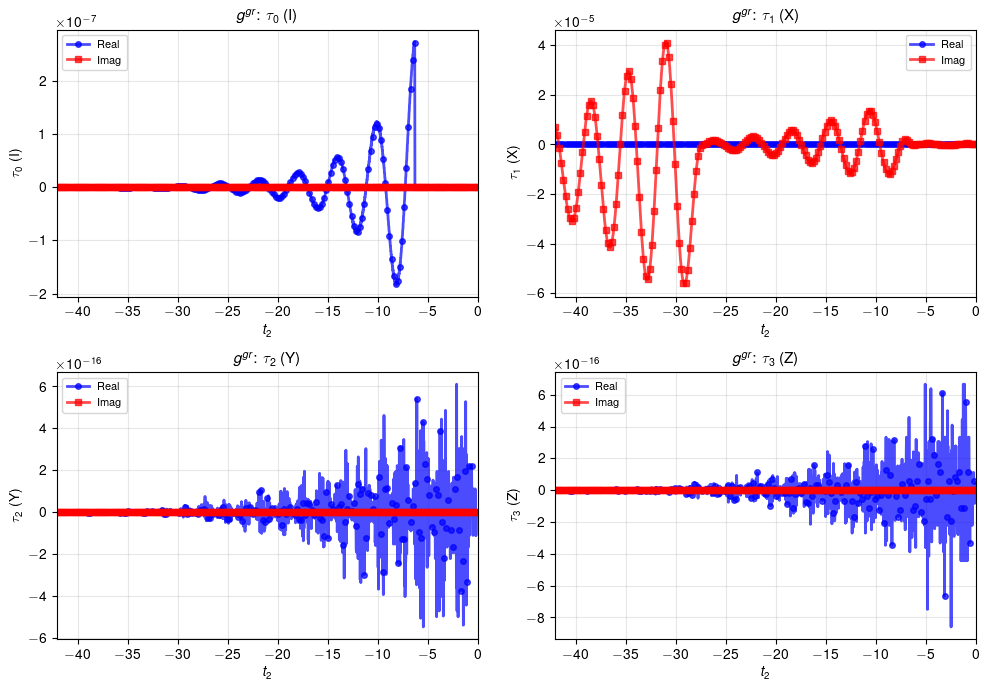


PLOTTING GK NORMALIZATION - Error Values

τ_0 component:
  Plotting range: [-9.2704e-18, 2.7297e-17]
  Mean error: 8.8731e-18
  Std deviation: 8.0425e-18
  Max error: 1.3449e-01

τ_1 component:
  Plotting range: [-2.5998e-05, 4.2580e-02]
  Mean error: 2.2846e-05
  Std deviation: 9.5169e-04
  Max error: 4.2580e-02

τ_2 component:
  Plotting range: [-2.4652e-32, 2.6482e-32]
  Mean error: 2.0479e-34
  Std deviation: 4.5111e-33
  Max error: 1.4988e-15

τ_3 component:
  Plotting range: [-1.3790e-31, 1.0708e-31]
  Mean error: 7.7065e-34
  Std deviation: 2.2030e-32
  Max error: 4.9405e-15



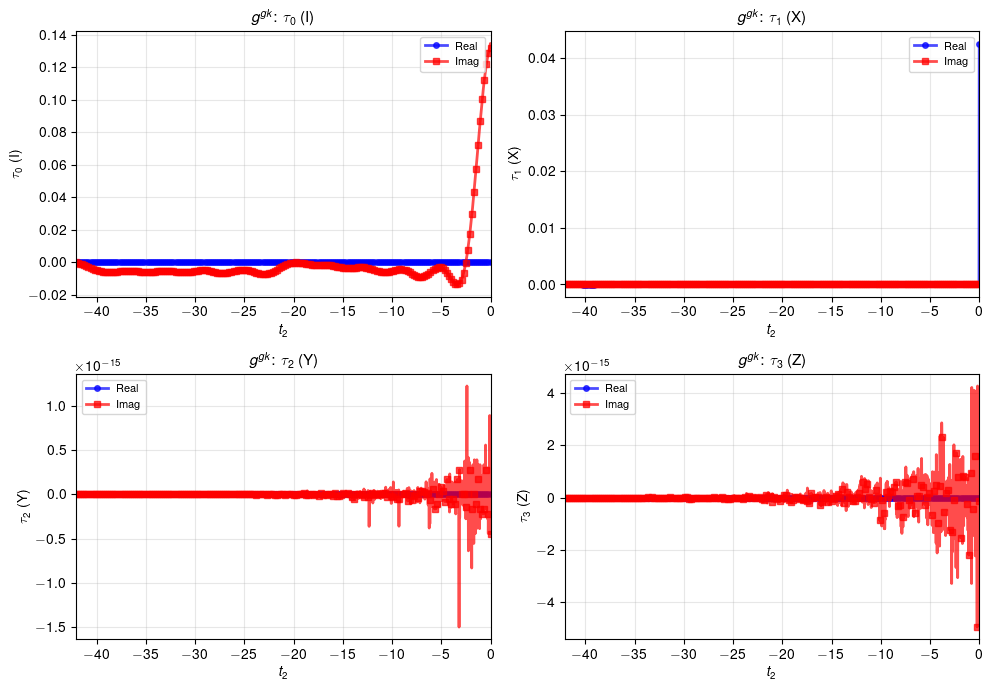

  gr errors per channel:
    τ₀: 2.73e-07
    τ₁: 5.64e-05
    τ₂: 6.11e-16
    τ₃: 8.60e-16
  gr max error: 5.64e-05 (in channel τ₁)

  gk errors per channel:
    τ₀: 1.34e-01
    τ₁: 4.26e-02
    τ₂: 1.50e-15
    τ₃: 4.94e-15
  gk max error: 1.34e-01 (in channel τ₀)


In [13]:
# Check gr and gk normalization relations
norm_results = da.check_normalizations(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']

print(f"  gr errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gr_max_error'][i]:.2e}")
gr_max_idx = np.argmax(norm_results['gr_max_error'])
print(f"  gr max error: {norm_results['gr_max_error'][gr_max_idx]:.2e} (in channel {pauli_names[gr_max_idx]})")

print(f"\n  gk errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gk_max_error'][i]:.2e}")
gk_max_idx = np.argmax(norm_results['gk_max_error'])
print(f"  gk max error: {norm_results['gk_max_error'][gk_max_idx]:.2e} (in channel {pauli_names[gk_max_idx]})")

-1
1

FDT CHECK - Maximum Error Indices

τ_0 component:
  max_error = 1.7764e-15 at index 1909
  error_at_last_element = -6.1630e-33 + 0.0000e+00j

τ_1 component:
  max_error = 1.9984e-15 at index 1908
  error_at_last_element = 0.0000e+00 + -1.9205e-33j

τ_2 component:
  max_error = 1.2602e-01 at index 1994
  error_at_last_element = 0.0000e+00 + -6.2047e-02j

τ_3 component:
  max_error = 4.5850e-03 at index 0
  error_at_last_element = 1.6670e-17 + 0.0000e+00j



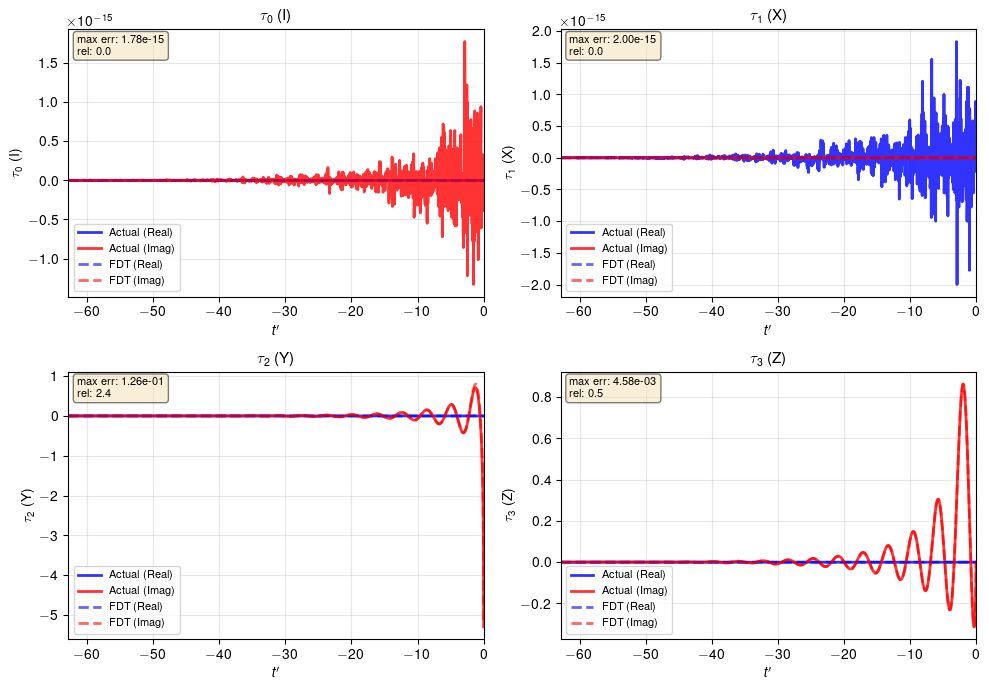


FDT Check Results:
  Errors per channel:
    τ₀: 1.78e-15
    τ₁: 2.00e-15
    τ₂: 1.26e-01
    τ₃: 4.58e-03
  Max error: 1.26e-01 (in channel τ₂)


In [13]:
# Check fluctuation-dissipation theorem
fdt_results = da.check_fdt(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']
print(f"\nFDT Check Results:")
print(f"  Errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {fdt_results['max_error'][i]:.2e}")
max_idx = np.argmax(fdt_results['max_error'])
print(f"  Max error: {fdt_results['max_error'][max_idx]:.2e} (in channel {pauli_names[max_idx]})")

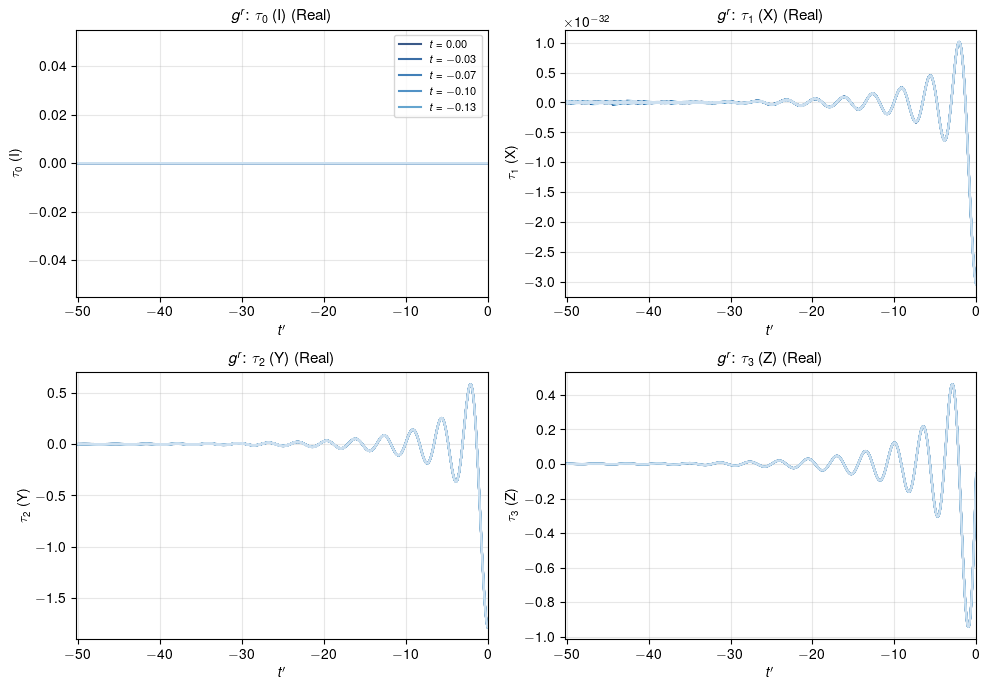

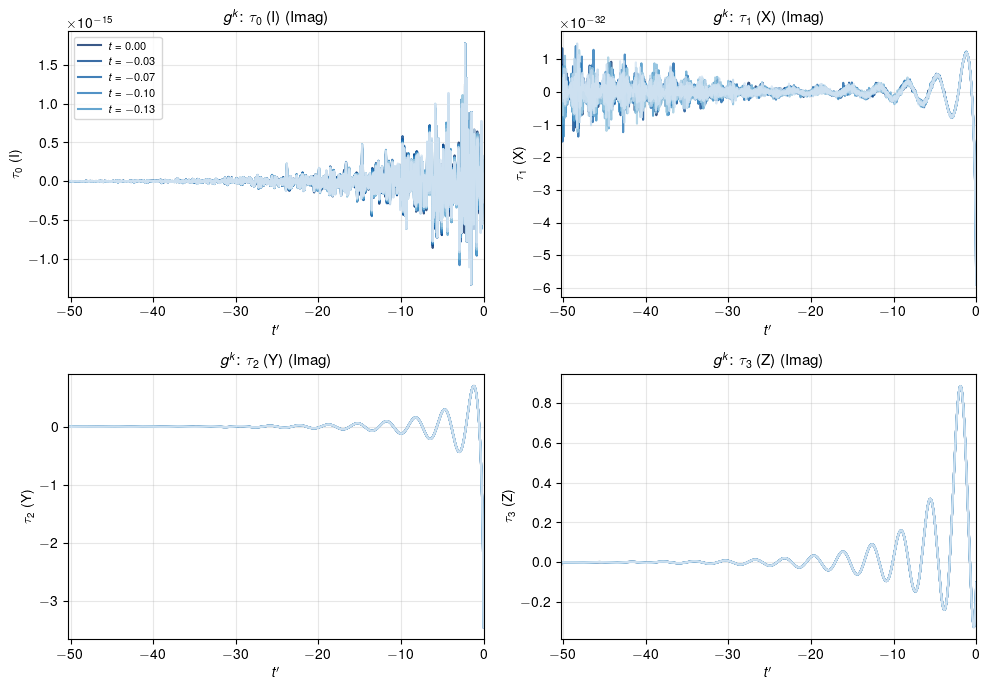


Time-Translation Invariance Results:
  gr max diffs per row: [0.0, np.float64(1.7944176971811001), np.float64(1.7944176971811001), np.float64(1.7944176971811001), np.float64(1.7944176971811001), np.float64(1.7944176971811001), np.float64(1.7944176971811001), np.float64(1.7944176971811001), np.float64(1.7944176971811001), np.float64(1.7944176971811001)]
  gr max diff: 1.79e+00 (in row 2 from last)

  gk max diffs per row: [0.0, np.float64(5.329804132930112), np.float64(5.329804132930112), np.float64(5.329804132930112), np.float64(5.329804132930112), np.float64(5.329804132930112), np.float64(5.329804132930112), np.float64(5.329804132930112), np.float64(5.329804132930112), np.float64(5.420892948063022)]
  gk max diff: 5.42e+00 (in row 10 from last)

  Passed (threshold 1e-08): False


In [ ]:
# Check time-translation invariance (equilibrium test)
tti_results = da.check_time_translational_invariance(check_timestamp, check_job_index,
                                                      num_rows=10, threshold=1e-8, save_plot=False)

print(f"\nTime-Translation Invariance Results:")
print(f"  gr max diffs per row: {tti_results['max_diff_gr']}")
gr_max_idx = np.argmax(tti_results['max_diff_gr'])
print(f"  gr max diff: {tti_results['max_diff_gr'][gr_max_idx]:.2e} (in row {gr_max_idx + 1} from last)")

print(f"\n  gk max diffs per row: {tti_results['max_diff_gk']}")
gk_max_idx = np.argmax(tti_results['max_diff_gk'])
print(f"  gk max diff: {tti_results['max_diff_gk'][gk_max_idx]:.2e} (in row {gk_max_idx + 1} from last)")

print(f"\n  Passed (threshold {tti_results['threshold']:.0e}): {tti_results['passed']}")

# 2. Gap and Current Analysis

In [27]:
evolution_timestamp = '1782196465'
evolution_job_index = 7
equilibrium_timestamp = '1782196485'

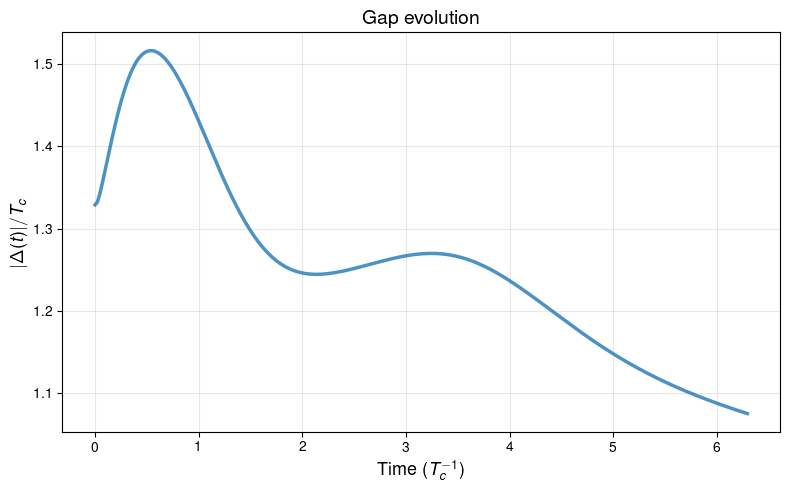

In [28]:
# Plot gap evolution for this job
da.plot_gap(evolution_timestamp, evolution_job_index, save_plot=False)

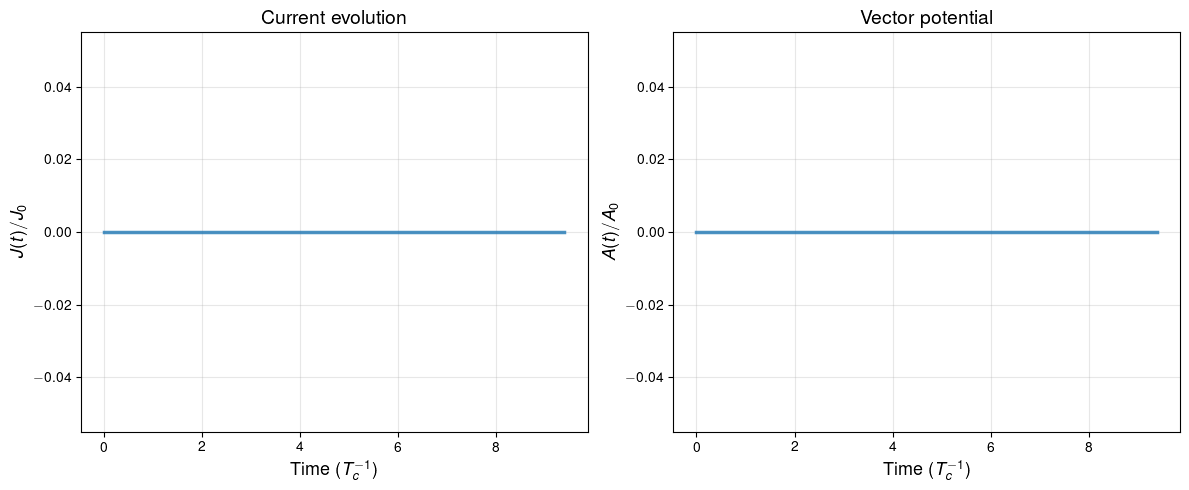

In [16]:
# Plot current evolution for this job
da.plot_current(evolution_timestamp, evolution_job_index, save_plot=False)



Parameter validation (evolution vs equilibrium):
  eta: 0.1 ✓
  Evolution: 0.7
  Equilibrium: 0.1
  critical_temperature: 1 ✓
  Total time duration: 0.000000 ✓

Loading equilibrium sweep data...
Loaded equilibrium data: 12 points from A=0.000 to 0.000

Job 6: Plotting 300 points
  Gap range: [1.253, 1.325]
  Current range: [0.000, 0.000]
  A range: [0.000e+00, 0.000e+00]
  Time range: [0.000, 9.393]


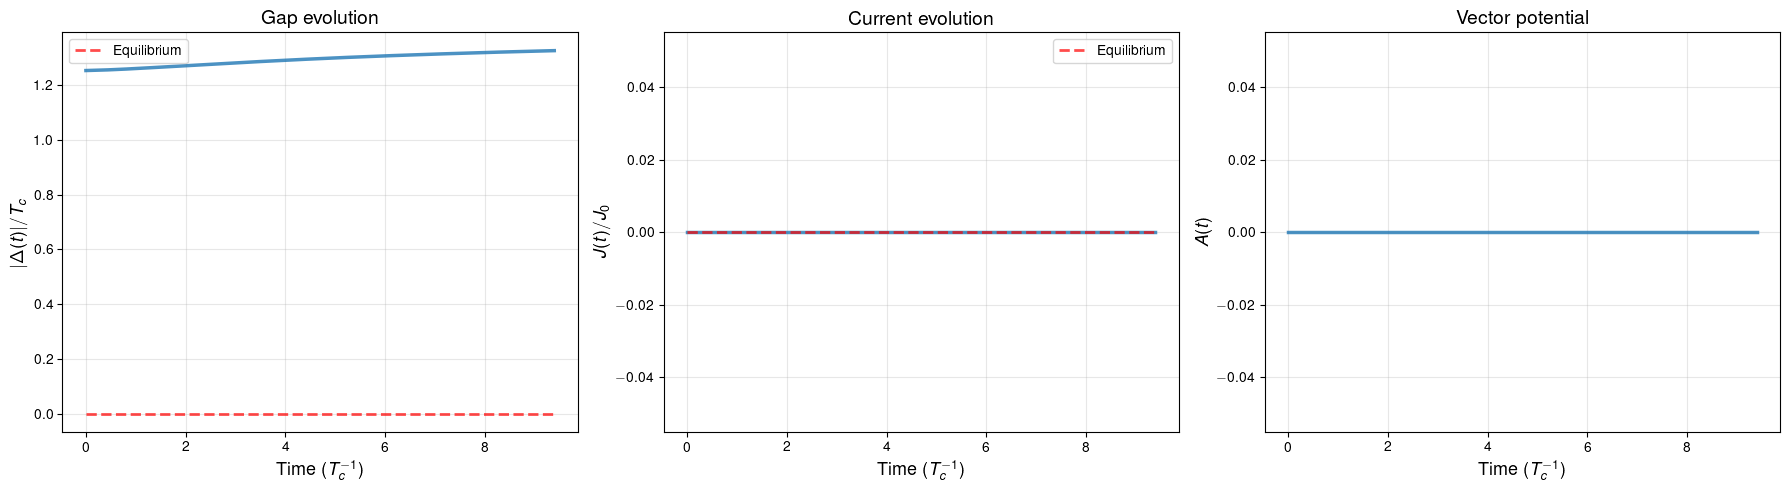

In [17]:
da.plot_gap_current_combined(
      timestamp=evolution_timestamp,           # Your time evolution run
      job_index=6,                      # Specific job to plot
      equilibrium_timestamp=equilibrium_timestamp,  # Your equilibrium sweep run
      n_average=100,                    # Average last 100 timesteps for equilibrium
      save_plot=False                    # Save to Figures/
  )


# 3. Parameter Sweep Analysis

Run this section to compare equilibrated gap/current across multiple timestamps.

In [14]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1782196465']  # Add more timestamps as needed: ['ts1', 'ts2', ...]
#'1781865083', 1781702763
# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'temperature'

# Number of final timesteps to average for equilibration
n_average = 50

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: temperature
Timestamps to analyze: ['1782196465']
Averaging last 50 timesteps


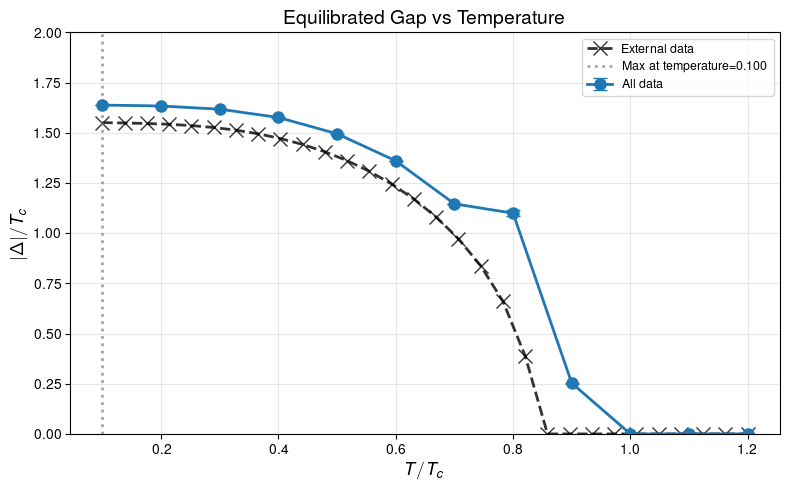


Gap Sweep Results:
  Parameter values: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2]
  Gap means: [ 1.63843323e+00-5.17102327e-34j  1.63385648e+00-1.75944509e-33j
  1.61786560e+00-2.92737700e-32j  1.57664965e+00-1.53067006e-33j
  1.49535749e+00-7.54721754e-33j  1.36048400e+00-5.52377415e-35j
  1.14633930e+00-1.24175314e-33j -1.09968554e+00+2.39466137e-31j
  2.52864846e-01-2.38916548e-33j  5.39869064e-11+0.00000000e+00j
  2.80717144e-09+0.00000000e+00j  2.19332840e-14+0.00000000e+00j]
  Gap errors: [7.21095574e-04 7.34123280e-04 7.54366770e-04 7.42556122e-04
 7.77420200e-04 7.39514779e-04 7.03331123e-04 1.56640748e-02
 2.44057873e-03 4.17183444e-12 3.97751078e-10 4.53538146e-15]

Maximum Gap:
  Max |Δ| = 1.6384
  At temperature = 0.1000


In [15]:
# Plot equilibrated gap vs parameter
gap_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps, 
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, combine_timestamps = True,
    x_external = eq_T, y_external = eq_gap_mag_T
)


print(f"\nGap Sweep Results:")
print(f"  Parameter values: {gap_sweep_results['parameter_values']}")
print(f"  Gap means: {gap_sweep_results['gap_means']}")
print(f"  Gap errors: {gap_sweep_results['gap_errors']}")
print(f"\nMaximum Gap:")
print(f"  Max |Δ| = {gap_sweep_results['max_gap']:.4f}")
print(f"  At {sweep_parameter} = {gap_sweep_results['max_parameter']:.4f}")

In [ ]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1781702934']  # Add more timestamps as needed: ['ts1', 'ts2', ...]
#['1781703060', '1781703037', '1781702934']
# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'vector_potential'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: vector_potential
Timestamps to analyze: ['1781702934']
Averaging last 100 timesteps


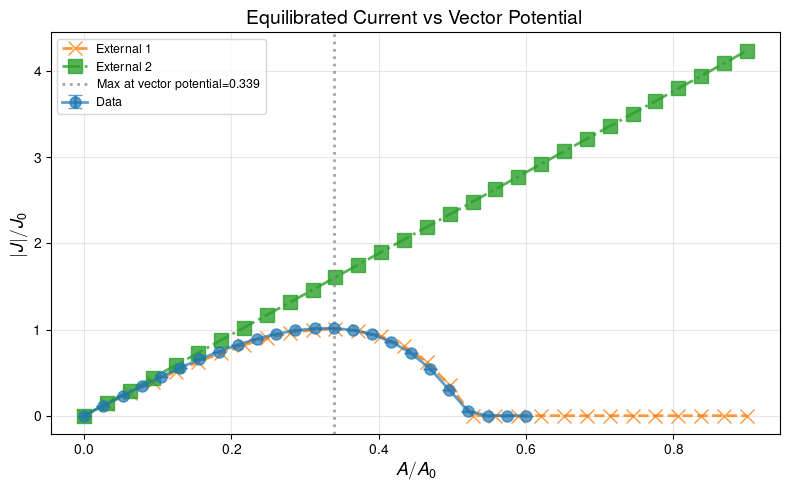

In [ ]:
# Plot equilibrated current vs parameter

current_sweep_results = da.plot_equilibrated_current_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = [eq_A,eq_A], y_external = [eq_current_A, eq_A * np.pi * 1.51812789 * np.tanh(1.51812789/2 / 0.3)]
)
#* added 1/2 factor for comparison since original current heory was wrong so to rescale. -- fixed in new version 

#print(np.pi * 1.51812789 * np.tanh(1.51812789/2 / 0.3)/2)
#print(np.max(eq_current_A))

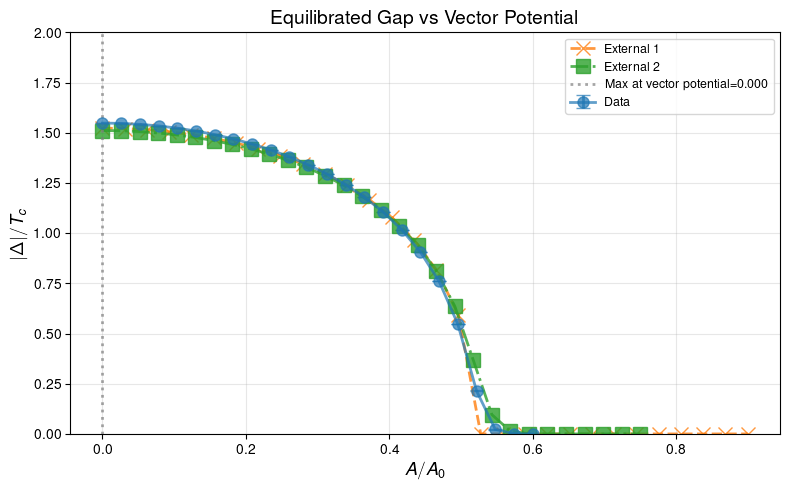

In [ ]:
x_jon = [0.        , 0.02586207 ,0.05172414 ,0.07758621 ,0.10344828, 0.12931034,
 0.15517241, 0.18103448, 0.20689655, 0.23275862, 0.25862069, 0.28448276,
 0.31034483, 0.3362069 , 0.36206897, 0.38793103, 0.4137931,  0.43965517,
 0.46551724, 0.49137931, 0.51724138, 0.54310345, 0.56896552, 0.59482759,
 0.62068966, 0.64655172, 0.67241379, 0.69827586, 0.72413793, 0.75]
y_jon = [1.51163408e+00, 1.51027885e+00, 1.50620005e+00, 1.49935768e+00,
 1.48968270e+00, 1.47707321e+00, 1.46138854e+00, 1.44244072e+00,
 1.41998222e+00, 1.39368837e+00, 1.36313217e+00, 1.32774717e+00,
 1.28677174e+00, 1.23916228e+00, 1.18345224e+00, 1.11750939e+00,
 1.03808374e+00, 9.39867391e-01, 8.13187470e-01, 6.36954560e-01,
 3.67131713e-01, 9.64004201e-02, 1.35302658e-02, 1.55015802e-03,
 1.64641301e-04, 1.68474568e-05, 1.68997743e-06, 1.67848029e-07,
 1.66168484e-08, 9.13836357e-09]

# Plot equilibrated current vs parameter
current_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = [eq_A,x_jon], y_external = [eq_gap_mag_A,y_jon]
)




# 4. Quasi-particle evolution dynamics 

In [ ]:
qp_timestamp = '1781888168'
qp_job_index = 0    


Energy-Time Plot (timestamp=1781888168, job_index=0):
  Green's function type: g^f
  Pauli components: (2, 3)
  Total time slices available: 5
  Plotting every 150 slice(s): 1 lines
  Time range: [0.00, 0.08]
  Energy grid points: 751



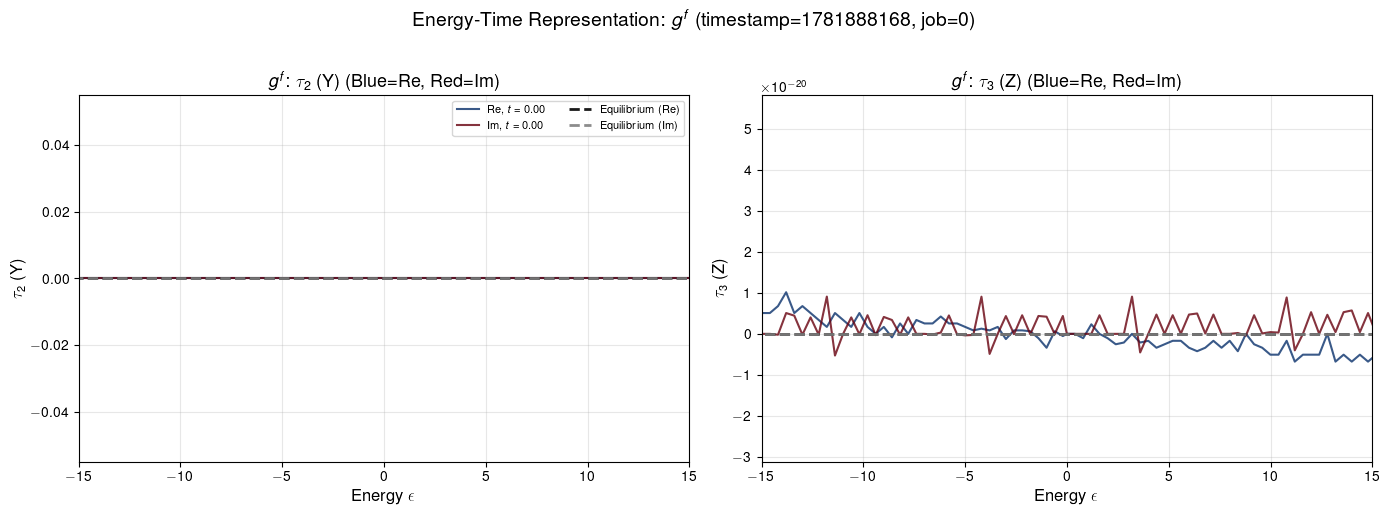

{'energy_grid': array([-149.70019987, -149.30046636, -148.90073284, -148.50099933,
        -148.10126582, -147.70153231, -147.3017988 , -146.90206529,
        -146.50233178, -146.10259827, -145.70286476, -145.30313125,
        -144.90339773, -144.50366422, -144.10393071, -143.7041972 ,
        -143.30446369, -142.90473018, -142.50499667, -142.10526316,
        -141.70552965, -141.30579614, -140.90606262, -140.50632911,
        -140.1065956 , -139.70686209, -139.30712858, -138.90739507,
        -138.50766156, -138.10792805, -137.70819454, -137.30846103,
        -136.90872751, -136.508994  , -136.10926049, -135.70952698,
        -135.30979347, -134.91005996, -134.51032645, -134.11059294,
        -133.71085943, -133.31112592, -132.91139241, -132.51165889,
        -132.11192538, -131.71219187, -131.31245836, -130.91272485,
        -130.51299134, -130.11325783, -129.71352432, -129.31379081,
        -128.9140573 , -128.51432378, -128.11459027, -127.71485676,
        -127.31512325, -126.91538

In [ ]:
da.plot_energy_time_representation(
    timestamp=qp_timestamp,  # Your timestamp
    job_index=qp_job_index,    # Your job index
    green_function_type='f',
    pauli_components=(2, 3),  # tau_0 and tau_3
    plot_every= 150,             # Plot every 5th time sl
    
    save_plot=True
)


# 5. Linear response -- Conductivity 

Max |A(t)| = 9.985e-02

Time-domain boundary values:
  A(t_start) = 0.000e+00+0.000e+00j, A(t_end) = 0.000e+00+0.000e+00j
  j(t_start) = 0.000e+00+0.000e+00j, j(t_end) = 7.628e-07-1.399e-38j
  Max |A(t)| = 9.985e-02
  Max |j(t)| = 4.165e-01

Conductivity Extraction (timestamp=1781818237, job_index=1):
  Time step (dt): 0.020944
  Total duration (T_total): 31.395
  Number of time points: 1500
  Frequency resolution (Δω): 0.200000
  Nyquist frequency (ω_max): 150.000
  Equilibrium gap (Δ₀): 1.405223
  Max |A(ω)|: 2.287e+00
  Threshold: 1.000e-03
  Valid frequency range: [-20.400, 20.400]
  Number of valid frequency points: 204/1500



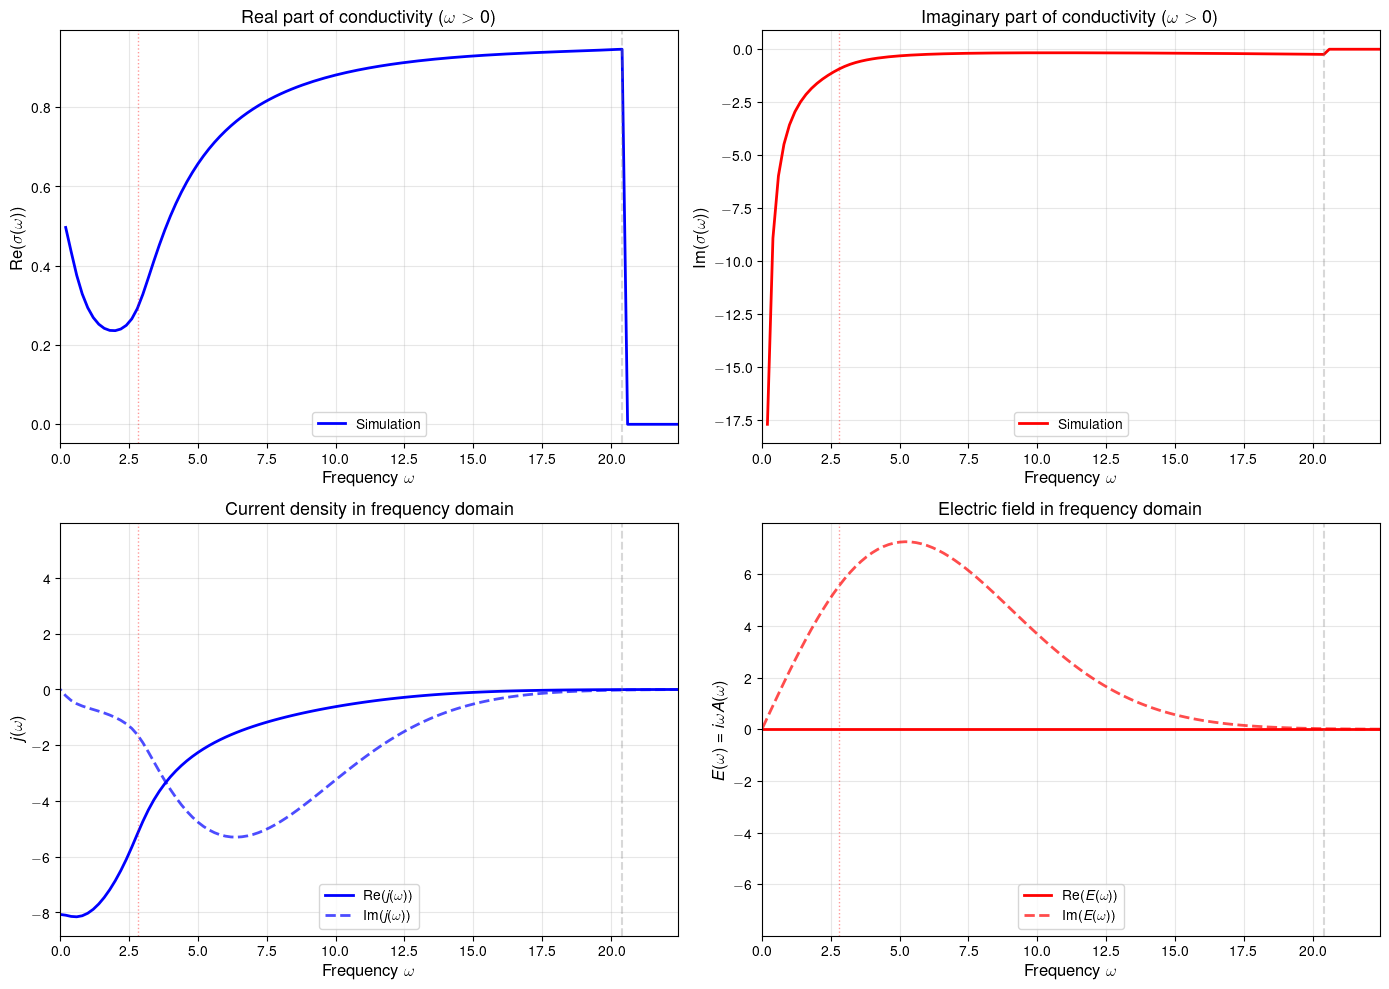

In [ ]:
timestamp = '1781818237'  # Your timestamp
job_index = 1  # Your job index

result = da.extract_conductivity(
    timestamp=timestamp,
    job_index=job_index,
    threshold=1e-3,  # Filter out noise where |A(ω)| is small
    save_plot=False,  # Save the plot    
    save_dir=None
)


## Error scaling analysis with $\delta t$ 


Comparing gap sweeps across 6 timestamps

Loading timestamp 1/6: 1782196299
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.01571$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.563165]

Loading timestamp 2/6: 1782196288
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.01795$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.566408]

Loading timestamp 3/6: 1782196259
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.02513$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.576554]

Loading timestamp 4/6: 1782196253
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.02094$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.570689]

Loading timestamp 5/6: 1782196249
  Loading 12 jobs (total available: 12)
  Label: $\Delta t = 0.03142$
  Sweep parameter range: [0.100000, 1.200000]
  Gap range: [0.000000, 1.585465]

Loading timestamp 6/6: 178219624

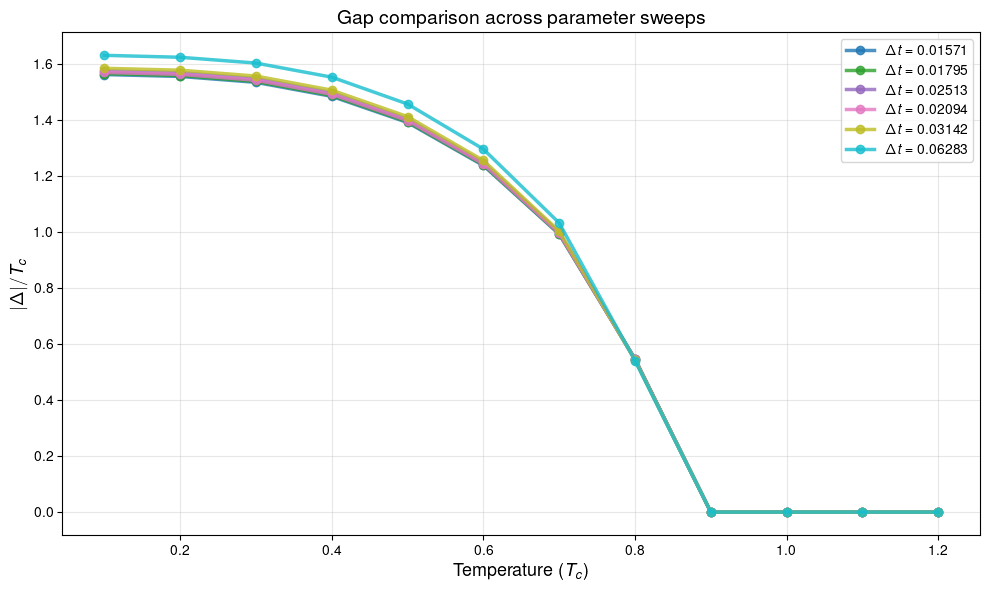

{'fig': <Figure size 1000x600 with 1 Axes>,
 'ax': <Axes: title={'center': 'Gap comparison across parameter sweeps'}, xlabel='Temperature ($T_c$)', ylabel='$|\\Delta| / T_c$'>,
 'data': [{'timestamp': '1782196299',
   'sweep_values': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2]),
   'gap_values': array([1.56316507e+00, 1.55636307e+00, 1.53533936e+00, 1.48534040e+00,
          1.39193570e+00, 1.23826317e+00, 9.93067700e-01, 5.47209917e-01,
          1.70658702e-06, 2.87525852e-12, 2.19980849e-13, 1.36384299e-16]),
   'label': '$\\Delta t = 0.01571$',
   'T_c': 1},
  {'timestamp': '1782196288',
   'sweep_values': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2]),
   'gap_values': array([1.56640845e+00, 1.55955885e+00, 1.53851751e+00, 1.48842582e+00,
          1.39478602e+00, 1.24060731e+00, 9.94271810e-01, 5.46621933e-01,
          1.76066557e-06, 9.88366696e-13, 1.97906661e-13, 4.60368547e-17]),
   'label': '$\\Delta t = 0.01795$',
   'T_c': 1},
 

In [8]:
da.compare_gap_across_timestamps(
      timestamps=['1782196299', '1782196288', '1782196259', '1782196253', '1782196249', '1782196242'],
      sweep_parameter='system_parameters.temperature',
      label_parameter='dt')